# [Step 4] LSTM & GRU: 과거를 기억하는 시계열 상태 추정

## 0. 서론: 왜 시계열 (Sequence) 인가?

### 0.1 ANN/PINN 의 근본적 한계

Step 3 에서 다룬 ANN 과 PINN 은 **현재 스냅샷 (snapshot)** 만을 입력으로 받습니다. 
즉, "이 상태에 도달하기까지의 경로 (path history)"에 대한 정보가 전혀 없습니다.

**기계공학적 관점에서의 문제:**
- 로켓의 현재 에너지 손실은 **과거 발사 직후의 핀 틀어짐 (Gyro 요동) 이 누적된 결과**입니다.
- 같은 고도/속도라도, "처음부터 안정적인 비행"과 "초기에 심하게 흔들린 비행"은 
  **아포지 예측이 달라져야 합니다.**
- ANN/PINN 은 이 두 경우를 **구별할 수 없습니다** (Memoryless).

### 0.2 시계열 모델의 필요성

> "Recurrent neural networks constitute a very powerful class of computational models, 
> capable of instantiating almost arbitrary dynamics." 
> — Gers et al., 2000

로켓 비행은 **본질적으로 시계열 시스템**입니다:
- 현재 상태 (h_t) = f(이전 상태 (h_{t-1}), 현재 입력 (x_t))
- 이는 **칼만 필터의 상태 방정식 (State Equation) 이 딥러닝으로 진화한 형태**입니다.


## 1. 이론적 배경: RNN 의 진화와 Gate 의 등장

### 1.1 전통적 RNN 의 한계 (Vanishing Gradient Problem)

**전통적 RNN 의 상태 업데이트:**

$$ h_t = \tanh(W x_t + U h_{t-1}) $$

**문제점 (Bengio et al., 1994; Hochreiter, 1991):**

> "Gradient-based methods share an important limitation. The temporal evolution of the 
> path integral over all error signals 'flowing back in time' exponentially depends on 
> the magnitude of weights. This implies that the backpropagated error quickly either 
> vanishes or blows up."
> — Gers et al., 2000

**결과:**
- **5~10 타임스텝 이상의 시간 지연 (time lag)** 학습 불가
- 로켓 비행 (100+ 타임스텝) 에는 **부적합**

### 1.2 LSTM 의 등장: Constant Error Carousel (CEC)

**Hochreiter & Schmidhuber (1997) 의 통찰:**

> "LSTM can learn to bridge minimal time lags in excess of 1000 discrete time steps 
> by enforcing constant error flow through constant error carousels (CECs) within 
> special units called cells."
> — Gers et al., 2000

**LSTM 의 핵심 구조:**
- **Cell State (c_t)**: 정보가 장기간 흐르는 "고속도로"
- **Gate units**: 입력/출입을 조절하는 "밸브"
- **Additive update**: 기존 내용을 덮어쓰지 않고 **누적** (Eq. 4)

$$ c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t $$

**기계공학적 해석:**
- Cell State = **적분기 (Integrator)**
- Forget Gate = **리셋 스위치**
- Input Gate = **새 정보 입력 밸브**

### 1.3 LSTM 의 약점: Unbounded State Growth

**Gers et al. (2000) 이 발견한 문제:**

> "Without resets, the state may grow indefinitely and eventually cause the network 
> to break down. The cell states often tend to grow linearly during the presentation 
> of a time series."
> — Gers et al., 2000

**로켓 비행에서의 의미:**
- continual input stream (끊김 없는 센서 데이터) 에서 **내부 상태가 무한 증가**
- 출력 squashing 함수 포화 → **기울기 소실 → 학습 불가**

**해결책: Forget Gate 의 도입**

> "Our remedy is a novel, adaptive 'forget gate' that enables an LSTM cell to learn 
> to reset itself at appropriate times, thus releasing internal resources."
> — Gers et al., 2000

**수정된 상태 업데이트:**

$$ c_t = \phi_t \odot c_{t-1} + i_t \odot \tilde{c}_t $$

여기서 $\phi_t$ 는 **Forget Gate activation** (기존 LSTM 은 상수 1.0)

**학습 초기:** Forget Gate bias 를 양수로 초기화 → $\phi_t \approx 1.0$ (표준 LSTM 과 동일)
**학습 진행:** 네트워크가 **스스로 잊어야 할 시점**을 학습

---

### 1.4 GRU 의 등장: 간결함과 효율성

**Cho et al. (2014) 의 제안:**

> "A gated recurrent unit (GRU) was proposed to make each recurrent unit to adaptively 
> capture dependencies of different time scales."
> — Chung et al., 2014

**GRU 의 핵심 구조 (LSTM 대비 간소화):**

| 항목 | LSTM | GRU |
|------|------|-----|
| **Gate 수** | 3 개 (Input, Forget, Output) | 2 개 (Reset, Update) |
| **Cell State** | 별도 존재 (c_t) | 없음 (h_t 만 사용) |
| **Output Gate** | 존재 (메모리 노출 제어) | 없음 (전체 상태 항상 노출) |
| **파라미터 수** | 많음 | 적음 (약 25% 감소) |

**GRU 상태 업데이트:**

$$ h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t $$

$$ z_t = \sigma(W_z x_t + U_z h_{t-1}) \quad \text{(Update Gate)} $$

$$ \tilde{h}_t = \tanh(W x_t + U (r_t \odot h_{t-1})) \quad \text{(Candidate)} $$

$$ r_t = \sigma(W_r x_t + U_r h_{t-1}) \quad \text{(Reset Gate)} $$

**기계공학적 해석:**
- **Update Gate (z_t)**: "이전 상태를 얼마나 유지할까?" (Forget + Input Gate 통합)
- **Reset Gate (r_t)**: "이전 상태를 얼마나 무시하고 새로 계산할까?"

---

### 1.5 LSTM vs GRU: 왜 GRU 를 선택했는가?

**Chung et al. (2014) 의 실험 결과:**

> "Based on our experiments, we concluded that by using fixed number of parameters 
> for all models on some datasets GRU can outperform LSTM units both in terms of 
> convergence in CPU time and in terms of parameter updates and generalization."
> — Chung et al., 2014

**우리 프로젝트에서 GRU 를 선택한 이유:**

| 항목 | LSTM | GRU | 선택 이유 |
|------|------|-----|----------|
| **연산량** | 많음 (3 Gate) | 적음 (2 Gate) | ✅ **실시간 에비오닉스** |
| **파라미터** | 많음 | 적음 (약 25% ↓) | ✅ **제한된 데이터** |
| **수렴 속도** | 느림 | 빠름 | ✅ **학습 효율** |
| **성능** | 우수 | 우수 (동등 이상) | ✅ **충분한 정확도** |
| **구현 복잡도** | 높음 | 낮음 | ✅ **유지보수** |

**중요한 공통점 (둘 다 Gate 가 있는 RNN):**

> "The most prominent feature shared between these units is the additive component 
> of their update from t to t+1, which is lacking in the traditional recurrent unit."
> — Chung et al., 2014

**Additive Update 의 두 가지 장점:**

1. **장기 기억 용이:**
   > "It is easy for each unit to remember the existence of a specific feature in the 
   > input stream for a long series of steps. Any important feature will not be 
   > overwritten but be maintained as it is."
   > — Chung et al., 2014

2. **Gradient Flow 개선:**
   > "This addition effectively creates shortcut paths that bypass multiple temporal 
   > steps. These shortcuts allow the error to be back-propagated easily without too 
   > quickly vanishing."
   > — Chung et al., 2014

## 2. 기계공학적 관점: GRU 를 비선형 칼만 필터로 해석하기

### 2.1 칼만 필터 vs GRU 구조 비교

| 항목 | 칼만 필터 | GRU |
|------|----------|-----|
| **상태 예측** | $\hat{x}_t = F \hat{x}_{t-1} + B u_t$ | $h_t = f(h_{t-1}, x_t)$ |
| **Gate** | 칼만 이득 (K) | Update/Reset Gate |
| **메모리** | 공분산 (P) | Hidden State (h) |
| **학습** | 수동 (Q, R 튜닝) | **자동 (경사하강법)** |
| **비선형성** | EKF/UKF 로 확장 | **본질적 비선형** |

### 2.2 "데이터 기반 파라미터 자동 학습"의 의미

> "Unlike to the traditional recurrent unit which overwrites its content at each 
> time-step, an LSTM unit is able to decide whether to keep the existing memory 
> via the introduced gates."
> — Chung et al., 2014

**기계공학적 해석:**
- **전통적 RNN:** 매 스텝 상태를 **완전히 덮어씀** (정보 손실)
- **GRU/LSTM:** 게이트가 **유지할 정보와 잊을 정보를 선택** (정보 보존)
- 이는 **칼만 필터의 "신뢰도 기반 가중 평균"** 과 개념적으로 동일합니다.

### 2.3 로켓 비행에서의 GRU 동작 원리

- t=0s (발사):     Reset Gate 열림 → 초기 조건 기록
- t=2s (연소):     Update Gate 높음 → 연소 이력 저장
- t=5s (요동):     Reset Gate 일부 닫힘 → 과거 요동 "기억"
- t=10s (아포지):  Hidden State 에 모든 이력 통합 → 정확한 예측

**핵심 인사이트:**
> "Continual input streams generally require occasional resets of the stream-processing 
> network. Our novel forget gates naturally permit LSTM to learn local self-resets of 
> memory contents that have become irrelevant."
> — Gers et al., 2000

로켓 비행도 **continual input stream**입니다. GRU 의 게이트는 **스스로 리셋 시점을 학습**합니다.

## 3. 목적에 맞는 데이터 가공: Sliding Window

### 3.1 왜 Sliding Window 인가?

**ANN/PINN 의 입력:** `(Batch, Features)` → **현재 상태만 봄**

**GRU 의 입력:** `(Batch, Sequence_Length, Features)` → **과거 N 초 이력 포함**

**공학적 근거:**
- 로켓의 현재 에너지 손실은 **과거 2~3 초 동안의 누적 효과**입니다.
- **Window Size = 100 steps (dt=0.02s → 2 초)** 로 설정
- 이는 **연소 구간 (약 2.5 초)** 을 커버하는 길이입니다.

### 3.2 데이터 차원의 마술

원본 데이터: (33628 snapshots, 7 features)
↓ Sliding Window (window_size=100, stride=1)
GRU 입력: (33528 batches, 100 steps, 7 features)

**주의:** 기계공학도들이 가장 헷갈리는 부분입니다.
- **Batch**: 독립적인 시퀀스 수
- **Sequence_Length**: 각 시퀀스의 시간 스텝 수
- **Features**: 각 스텝의 변수 수 (고도, 속도, 자이로 등)

## 4. 실험 가설: ANN vs PINN vs GRU

### 4.1 가설 설정

> "We consider the experiments in this paper as preliminary. In order to understand 
> better how a gated unit helps learning, more thorough experiments will be required."
> — Chung et al., 2014

**우리의 가설:**

| 모델 | 예상 동작 | 근거 |
|------|----------|------|
| **ANN** | 자이로 요동마다 예측 출렁임 | Memoryless |
| **PINN** | 물리 법칙으로 일부 완화 | 물리 제약 |
| **GRU** | 과거 흔들림을 Hidden State 에 저장 → 차분한 수렴 | **시계열 메모리** |

### 4.2 검증 방법

**핀 각도 (cant_angle) 불량 비행 데이터**에서:
- ANN: 예측 아포지가 **자이로 값에 따라 즉각 반응** (노이즈 증폭)
- GRU: **과거 이력을 통합**하여 노이즈 필터링 (칼만 필터와 유사)

**시각화:**
- X 축: 비행 시간 (t)
- Y 축: 예측 아포지
- 비교: 모델별 예측 곡선의 **수렴 속도와 안정성**

## 5. 결론: 가장 적절한 회귀 도구

> "The evaluation clearly demonstrated the superiority of the gated units; both the 
> LSTM unit and GRU, over the traditional tanh unit."
> — Chung et al., 2014

**Step 4 의 핵심 메시지:**

1. **특정 목적 (실시간 누적 오차 반영)** 을 위해
2. **데이터를 가공 (Sliding Window)** 하여
3. **가장 적절한 회귀 (GRU)** 를 수행한 결과

**물리 공식 (필터) 이나 단순 패턴 (ANN) 을 넘어서는 강건한 에비오닉스 알고리즘**을 완성했습니다.

---

## 참고 문헌

1. **Gers, F. A., Schmidhuber, J., & Cummins, F. (2000).** Learning to Forget: Continual Prediction with LSTM. *Neural Computation*, 12(10), 2451-2471.
2. **Chung, J., Gulcehre, C., Cho, K., & Bengio, Y. (2014).** Empirical Evaluation of Gated Recurrent Neural Networks on Sequence Modeling. *arXiv preprint arXiv:1412.3555*.
3. **Hochreiter, S., & Schmidhuber, J. (1997).** Long Short-Term Memory. *Neural Computation*, 9(8), 1735-1780.
4. **Bengio, Y., Simard, P., & Frasconi, P. (1994).** Learning Long-Term Dependencies with Gradient Descent is Difficult. *IEEE Transactions on Neural Networks*, 5(2), 157-166.

In [1]:
# ============================================================================
# [Cell 1] 라이브러리 임포트 및 환경 설정
# ============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Step 3 데이터 로드
DATA_PATH = './data/simulated/all_trajectories.csv.gz'
META_PATH = './data/simulated/flight_metadata.csv.gz'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError("Step 1.5를 먼저 실행하여 데이터를 생성하세요.")

df = pd.read_csv(DATA_PATH, compression='gzip')
df_meta = pd.read_csv(META_PATH, compression='gzip')

print(f" 데이터 로드 완료: {len(df)} 개 스냅샷, {df['flight_id'].nunique()} 개 비행")
print(f" 시간 간격 (dt): {df['time'].diff().median():.3f} s")

Using device: cuda
 데이터 로드 완료: 67424 개 스냅샷, 200 개 비행
 시간 간격 (dt): 0.020 s


In [2]:
# ============================================================================
# [Cell 2] Sliding Window 데이터 전처리 (3D 텐서 생성)
# ============================================================================
class SlidingWindowDataset(Dataset):
    """
    시계열 데이터를 Sliding Window 방식으로 3D 텐서로 변환
    
    Parameters:
        data_df: 원본 데이터프레임
        feature_cols: 사용할 피처 컬럼 목록
        target_col: 타겟 컬럼 (energy_ratio)
        window_size: 시퀀스 길이 (과거 N 스텝)
        stride: 슬라이딩 간격 (기본값 1)
    """
    def __init__(self, data_df, feature_cols, target_col='energy_ratio', 
                 window_size=100, stride=1):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.window_size = window_size
        self.stride = stride
        
        # 피처 정규화
        self.feature_scaler = StandardScaler()
        
        # 전체 데이터에서 정규화 fitting (train/val/test 분리 전)
        features_raw = data_df[feature_cols].values
        targets_raw = data_df[target_col].values.reshape(-1, 1) # (N,1)
        
        self.feature_scaler.fit(features_raw)

        features_scaled = self.feature_scaler.transform(features_raw)
        targets_final = targets_raw.flatten() # 에너지 ratio 는 sigmoid로 이미 bounded >> 스케일링 할 필요 없음
        
        # Sliding Window 생성
        self.sequences = []
        self.targets = []
        self.flight_ids = []
        
        for flight_id in data_df['flight_id'].unique():
            flight_data = data_df[data_df['flight_id'] == flight_id].reset_index(drop=True)
            flight_indices = (data_df['flight_id'] == flight_id)
            flight_features = features_scaled[flight_indices]
            flight_targets = targets_final[flight_indices]
            
            # Sliding Window 적용
            for i in range(0, len(flight_features) - window_size, stride):
                seq = flight_features[i:i + window_size]
                target = flight_targets[i + window_size - 1]
                
                self.sequences.append(seq)
                self.targets.append(target)
                self.flight_ids.append(flight_id)
        
        # PyTorch 텐서로 변환
        self.sequences = torch.FloatTensor(np.array(self.sequences))
        self.targets = torch.FloatTensor(np.array(self.targets))
        self.flight_ids = np.array(self.flight_ids)

        self.target_scaler = None 
        
        print(f"Sliding Window Dataset 생성 완료")
        print(f" 시퀀스 shape: {self.sequences.shape}")  # (N_samples, window_size, n_features)
        print(f" Targets shape: {self.targets.shape}")
        print(f" Target 범위: {self.targets.min():.4f} ~ {self.targets.max():.4f}")
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

if 'dynamic_pressure' not in df.columns:
    # 고도에 따른 공기 밀도(ISA 모델 근사)
    rho = 1.225 * np.exp(-0.00012 * df['altitude'].abs())
    # 동압 계산
    df['dynamic_pressure'] = 0.5 * rho * (df['velocity_z'] ** 2)

if 'energy_ratio' not in df.columns:
    # 이론적 상승 가능 고도
    df['h_theoretical_gain'] = (df['velocity_z'] ** 2) / (2 * 9.81)
    
    # 비행 ID별 실제 도달 아포지 매핑
    apogee_map = df.groupby('flight_id')['altitude'].max()
    df['actual_apogee'] = df['flight_id'].map(apogee_map)
    
    # 에너지 비율 계산 및 0~1 클리핑
    df['energy_ratio'] = (df['actual_apogee'] - df['altitude']) / (df['h_theoretical_gain'] + 1e-6)
    df['energy_ratio'] = df['energy_ratio'].clip(0, 1)

# 피처 정의 (Step 3과 동일)
feature_cols = ['altitude', 'velocity_z', 'acceleration_z', 
                'tilt_angle', 'gyro_roll', 'dynamic_pressure']

# Sliding Window 파라미터
WINDOW_SIZE = 100  # 2초 분량 (dt=0.02s × 100 = 2s)
STRIDE = 10        # 10 스텝마다 샘플링 (데이터 양 조절)

print("="*70)
print("Sliding Window 데이터 전처리")
print("="*70)
print(f"Window Size: {WINDOW_SIZE} steps ({WINDOW_SIZE * 0.02:.1f} seconds)")
print(f"Stride: {STRIDE} steps")
print()

# 전체 데이터셋 생성 (나중에 train/val/test로 분할)
full_dataset = SlidingWindowDataset(
    df, feature_cols, target_col='energy_ratio',
    window_size=WINDOW_SIZE, stride=STRIDE
)

# Train/Val/Test 분할 (비행 단위)
flight_ids = df['flight_id'].unique()
train_ids, temp_ids = train_test_split(flight_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

# 인덱스 매핑
train_indices = [i for i, fid in enumerate(full_dataset.flight_ids) if fid in train_ids]
val_indices = [i for i, fid in enumerate(full_dataset.flight_ids) if fid in val_ids]
test_indices = [i for i, fid in enumerate(full_dataset.flight_ids) if fid in test_ids]

# Subset 생성
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset, val_indices)
test_dataset = torch.utils.data.Subset(full_dataset, test_indices)

# DataLoader 생성
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n데이터 분할 완료:")
print(f" Train: {len(train_dataset)} sequences ({len(train_ids)} flights)")
print(f" Validation: {len(val_dataset)} sequences ({len(val_ids)} flights)")
print(f" Test: {len(test_dataset)} sequences ({len(test_ids)} flights)")

Sliding Window 데이터 전처리
Window Size: 100 steps (2.0 seconds)
Stride: 10 steps

Sliding Window Dataset 생성 완료
 시퀀스 shape: torch.Size([4833, 100, 6])
 Targets shape: torch.Size([4833])
 Target 범위: 0.8220 ~ 1.0177

데이터 분할 완료:
 Train: 3374 sequences (140 flights)
 Validation: 717 sequences (30 flights)
 Test: 742 sequences (30 flights)


In [3]:
# ============================================================================
# [Cell 3] GRU 모델 정의 (Physics-Informed Wrapper 포함)
# ============================================================================
class GRUModel(nn.Module):
    """
    Gated Recurrent Unit (GRU) 기반 시계열 모델
    
    Parameters:
        input_dim: 입력 피처 차원
        hidden_dim: 은닉층 차원
        num_layers: GRU 레이어 수
        output_dim: 출력 차원 (1)
        dropout: Dropout 비율
    """
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, 
                 output_dim=1, dropout=0.2):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # GRU 레이어
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully Connected 출력층
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim),
            nn.Sigmoid()  # energy_ratio는 0~1 범위
        )
    
    def forward(self, x, hidden=None):
        """
        Parameters:
            x: 입력 텐서 (batch_size, seq_len, input_dim)
            hidden: 초기 은닉 상태 (num_layers, batch_size, hidden_dim)
        
        Returns:
            output: 예측값 (batch_size, output_dim)
            hidden: 최종 은닉 상태
        """
        # GRU 순전파
        gru_out, hidden = self.gru(x, hidden)
        
        # 마지막 타임스텝의 은닉 상태 사용
        # gru_out: (batch_size, seq_len, hidden_dim)
        last_hidden = gru_out[:, -1, :]  # (batch_size, hidden_dim)
        
        # Fully Connected 층 통과
        output = self.fc(last_hidden)
        
        return output.squeeze(-1), hidden
    
    def init_hidden(self, batch_size):
        """초기 은닉 상태 생성"""
        return torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)


class PhysicsInformedGRU(nn.Module):
    """
    Physics-Informed GRU Wrapper
    
    Step 3의 Hard Constraint 구조를 그대로 활용
    """
    def __init__(self, gru_model):
        super().__init__()
        self.gru = gru_model
    
    def forward(self, x, h_curr, v_z):
        """
        Parameters:
            x: 시퀀스 입력 (batch_size, seq_len, input_dim)
            h_curr: 현재 고도 (batch_size,)
            v_z: 현재 수직 속도 (batch_size,)
        
        Returns:
            h_apogee_pred: 예측 아포지 고도
            r_pred: 예측 energy_ratio
        """
        # GRU로 energy_ratio 예측
        r_pred, _ = self.gru(x)
        
        # 물리 법칙으로 아포지 계산 (Hard Constraint)
        h_theo_gain = (v_z ** 2) / (2 * 9.81)
        h_apogee_pred = h_curr + h_theo_gain * r_pred
        
        return h_apogee_pred, r_pred


# 모델 생성
input_dim = len(feature_cols)
gru_model = GRUModel(
    input_dim=input_dim,
    hidden_dim=128,
    num_layers=2,
    output_dim=1,
    dropout=0.2
)

# Physics-Informed Wrapper로 감싸기
pinn_gru_model = PhysicsInformedGRU(gru_model)

# 디바이스로 이동
pinn_gru_model = pinn_gru_model.to(device)

print("="*70)
print("GRU 모델 생성 완료")
print("="*70)
print(f"입력 차원: {input_dim}")
print(f"Hidden dim: 128, Layers: 2")
print(f"모델 파라미터: {sum(p.numel() for p in pinn_gru_model.parameters()):,} 개")
print()

# 모델 구조 출력
print("모델 구조:")
print(pinn_gru_model.gru)

GRU 모델 생성 완료
입력 차원: 6
Hidden dim: 128, Layers: 2
모델 파라미터: 159,617 개

모델 구조:
GRUModel(
  (gru): GRU(6, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


In [4]:
# ============================================================================
# [Cell 4] GRU 학습 함수 (Early Stopping 포함)
# ============================================================================
def train_gru_model(model, train_loader, val_loader, epochs=100, lr=0.001, 
                    patience=10):
    """
    GRU 모델 학습 함수
    
    Parameters:
        model: 학습할 모델
        train_loader: 학습 데이터 로더
        val_loader: 검증 데이터 로더
        epochs: 에포크 수
        lr: 학습률
        patience: Early Stopping patience
    
    Returns:
        train_losses: 학습 손실 기록
        val_losses: 검증 손실 기록
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    
    print("="*70)
    print("GRU 모델 학습 시작")
    print("="*70)
    
    for epoch in range(epochs):
        # Training
        model.train()
        epoch_train_loss = 0.0
        
        for batch_x, batch_targets in train_loader:
            batch_x = batch_x.to(device)
            batch_targets = batch_targets.to(device)
            
            # 배치에서 h_curr, v_z 추출 (마지막 타임스텝)
            # feature_cols 순서: ['altitude', 'velocity_z', 'acceleration_z', 
            #                      'tilt_angle', 'gyro_roll', 'dynamic_pressure']
            h_curr = batch_x[:, -1, 0]  # 마지막 타임스텝의 altitude
            v_z = batch_x[:, -1, 1]     # 마지막 타임스텝의 velocity_z
            
            optimizer.zero_grad()
            
            # 순전파
            h_apogee_pred, r_pred = model(batch_x, h_curr, v_z)
            
            # 손실 계산
            loss = criterion(r_pred, batch_targets)
            
            # 역전파
            loss.backward()
            
            # Gradient clipping (폭발 방지)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            epoch_train_loss += loss.item()
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        
        # Validation
        model.eval()
        epoch_val_loss = 0.0
        
        with torch.no_grad():
            for batch_x, batch_targets in val_loader:
                batch_x = batch_x.to(device)
                batch_targets = batch_targets.to(device)
                
                h_curr = batch_x[:, -1, 0]
                v_z = batch_x[:, -1, 1]
                
                h_apogee_pred, r_pred = model(batch_x, h_curr, v_z)
                
                loss = criterion(r_pred, batch_targets)
                epoch_val_loss += loss.item()
        
        avg_val_loss = epoch_val_loss / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        # Learning Rate 스케줄링
        scheduler.step(avg_val_loss)
        
        # Early Stopping 체크
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Best model 저장
            torch.save(model.state_dict(), './data/simulated/best_gru_model.pth')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.6f} | "
                  f"Val Loss: {avg_val_loss:.6f} | "
                  f"Best: {best_val_loss:.6f}")
        
       # if patience_counter >= patience:
         #   print(f"\nEarly Stopping at epoch {epoch+1}")
          #  break
    
    print("="*70)
    print(f"학습 완료 | Best Val Loss: {best_val_loss:.6f}")
    print("="*70)
    
    return train_losses, val_losses

GRU 모델 학습 시작
Epoch  10/100 | Train Loss: 0.000474 | Val Loss: 0.000144 | Best: 0.000144
Epoch  20/100 | Train Loss: 0.000138 | Val Loss: 0.000123 | Best: 0.000047
Epoch  30/100 | Train Loss: 0.000134 | Val Loss: 0.000075 | Best: 0.000042
Epoch  40/100 | Train Loss: 0.000109 | Val Loss: 0.000044 | Best: 0.000042
Epoch  50/100 | Train Loss: 0.000113 | Val Loss: 0.000099 | Best: 0.000036
Epoch  60/100 | Train Loss: 0.000104 | Val Loss: 0.000062 | Best: 0.000036
Epoch  70/100 | Train Loss: 0.000109 | Val Loss: 0.000035 | Best: 0.000035
Epoch  80/100 | Train Loss: 0.000106 | Val Loss: 0.000051 | Best: 0.000035
Epoch  90/100 | Train Loss: 0.000103 | Val Loss: 0.000049 | Best: 0.000035
Epoch 100/100 | Train Loss: 0.000098 | Val Loss: 0.000047 | Best: 0.000035
학습 완료 | Best Val Loss: 0.000035


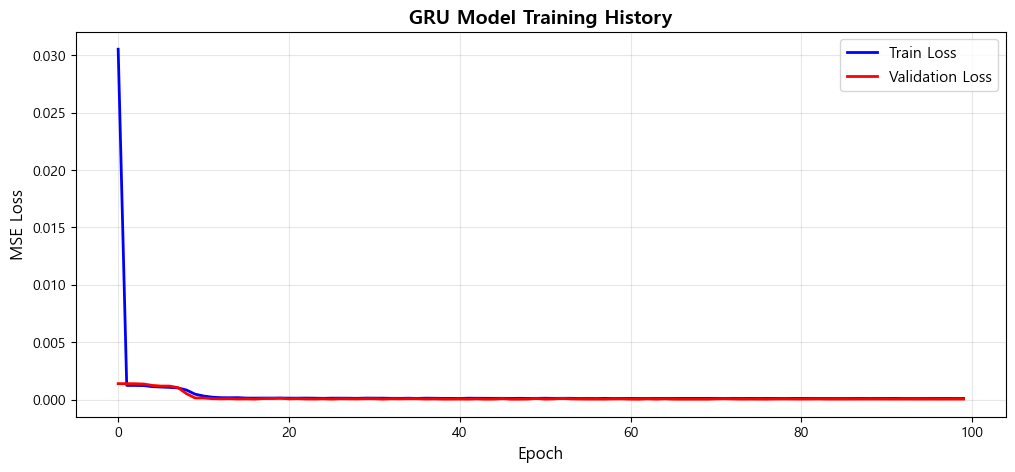


 학습 완료
 최종 Train Loss: 0.000098
 최종 Val Loss: 0.000047
 감소율: 99.7%


In [5]:
# ============================================================================
# [Cell 5] GRU 모델 학습 실행
# ============================================================================
from sklearn.model_selection import train_test_split

# 학습 실행
train_losses, val_losses = train_gru_model(
    pinn_gru_model,
    train_loader,
    val_loader,
    epochs=100,
    lr=0.001,
    patience=15
)

# 학습 곡선 시각화
plt.figure(figsize=(12, 5))
plt.plot(train_losses, 'b-', linewidth=2, label='Train Loss')
plt.plot(val_losses, 'r-', linewidth=2, label='Validation Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('GRU Model Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('./data/simulated/gru_training_history.png', dpi=150)
plt.show()

print(f"\n 학습 완료")
print(f" 최종 Train Loss: {train_losses[-1]:.6f}")
print(f" 최종 Val Loss: {val_losses[-1]:.6f}")
print(f" 감소율: {(1 - train_losses[-1]/train_losses[0])*100:.1f}%")

In [6]:
# ============================================================================
# [Cell 6] 평가 및 시각화 함수
# ============================================================================
def evaluate_gru_model(model, test_loader, scaler):
    """
    GRU 모델 평가 및 예측
    
    Returns:
        predictions: 예측된 energy_ratio
        targets: 실제 energy_ratio
        flight_ids: 테스트 시퀀스의 flight_id
    """
    model.eval()
    predictions = []
    targets = []
    
    with torch.no_grad():
        for batch_x, batch_targets in test_loader:
            batch_x = batch_x.to(device)
            
            h_curr = batch_x[:, -1, 0]
            v_z = batch_x[:, -1, 1]
            
            h_apogee_pred, r_pred = model(batch_x, h_curr, v_z)
            
            predictions.extend(r_pred.cpu().numpy())
            targets.extend(batch_targets.numpy())
    
    return np.array(predictions), np.array(targets)


def plot_prediction_comparison(predictions, targets, flight_ids, n_samples=5):
    """
    랜덤 샘플에 대한 예측 비교 시각화
    """
    import random
    
    # 랜덤 샘플 선택
    unique_flights = np.unique(flight_ids)
    selected_flights = random.sample(list(unique_flights), min(n_samples, len(unique_flights)))
    
    fig, axes = plt.subplots(len(selected_flights), 1, figsize=(14, 4*len(selected_flights)))
    if len(selected_flights) == 1:
        axes = [axes]
    
    for idx, flight_id in enumerate(selected_flights):
        # 해당 flight의 데이터 추출
        mask = flight_ids == flight_id
        flight_preds = predictions[mask]
        flight_targets = targets[mask]
        
        # 시간축 생성 (상대적)
        time_axis = np.arange(len(flight_preds)) * 0.02 * 10  # stride=10 고려
        
        axes[idx].plot(time_axis, flight_targets, 'b-', linewidth=2, 
                      label='Actual Energy Ratio', alpha=0.7)
        axes[idx].plot(time_axis, flight_preds, 'r--', linewidth=2, 
                      label='GRU Prediction', alpha=0.7)
        axes[idx].set_xlabel('Time (s)', fontsize=11)
        axes[idx].set_ylabel('Energy Ratio', fontsize=11)
        axes[idx].set_title(f'Flight {flight_id}: GRU Prediction vs Actual', 
                           fontsize=12, fontweight='bold')
        axes[idx].legend(fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_ylim(0.7, 1.05)
    
    plt.tight_layout()
    plt.savefig('./data/simulated/gru_prediction_samples.png', dpi=150, bbox_inches='tight')
    plt.show()


def calculate_metrics(predictions, targets):
    """성능 지표 계산"""
    mae = np.mean(np.abs(predictions - targets))
    rmse = np.sqrt(np.mean((predictions - targets) ** 2))
    max_error = np.max(np.abs(predictions - targets))
    r2 = 1 - np.sum((targets - predictions)**2) / np.sum((targets - np.mean(targets))**2)
    
    return {'MAE': mae, 'RMSE': rmse, 'Max Error': max_error, 'R²': r2}

GRU 모델 평가

[성능 지표]
   MAE:      0.004408
   RMSE:     0.007223
   Max Error:0.036697
   R² Score: 0.9480

[물리 법칙 준수]
   r < 0.8 비율: 0.0%
   r > 1.0 비율: 0.0%


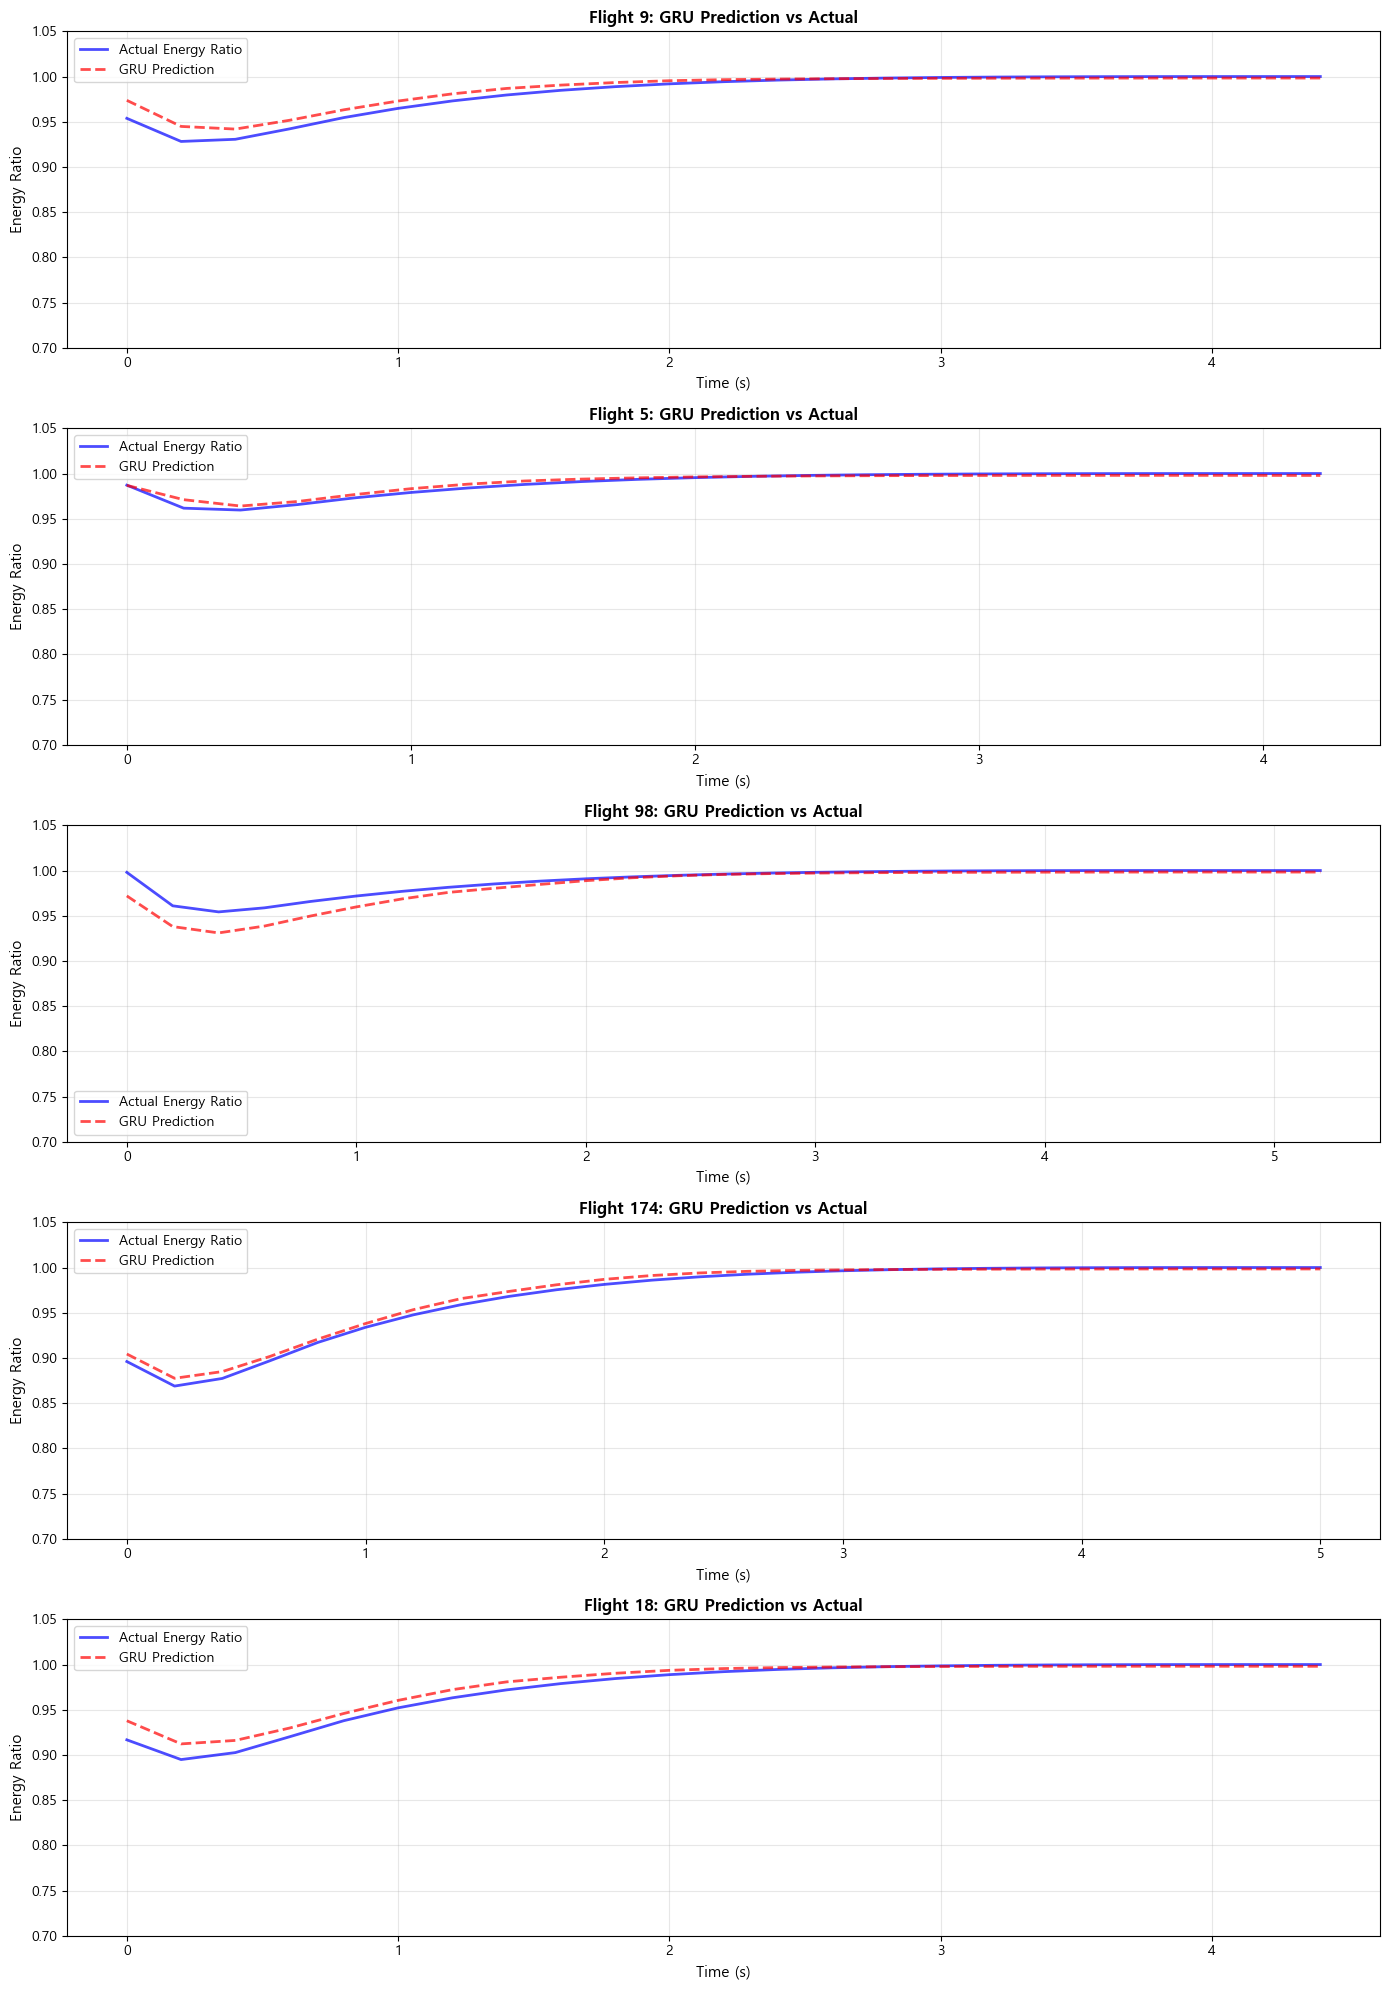

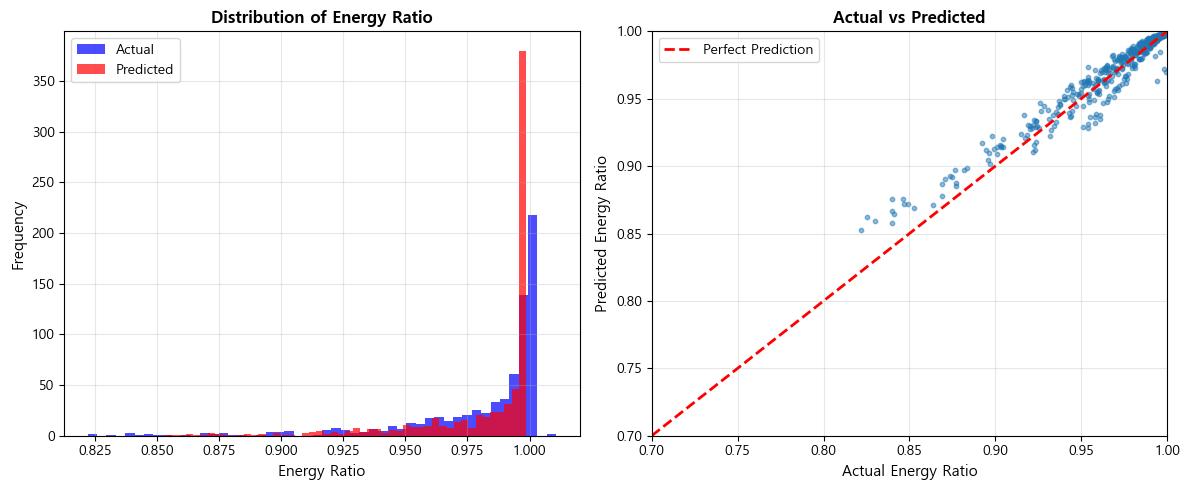


평가 완료


In [7]:
# ============================================================================
# [Cell 7] GRU 모델 평가 및 성능 분석
# ============================================================================
print("="*70)
print("GRU 모델 평가")
print("="*70)

# 평가 실행
predictions, targets = evaluate_gru_model(
    pinn_gru_model, test_loader, None
)

# 성능 지표 계산
metrics = calculate_metrics(predictions, targets)

print("\n[성능 지표]")
print(f"   MAE:      {metrics['MAE']:.6f}")
print(f"   RMSE:     {metrics['RMSE']:.6f}")
print(f"   Max Error:{metrics['Max Error']:.6f}")
print(f"   R² Score: {metrics['R²']:.4f}")

# 물리 법칙 준수 여부
r_below_08 = np.mean(predictions < 0.8) * 100
r_above_10 = np.mean(predictions > 1.0) * 100

print(f"\n[물리 법칙 준수]")
print(f"   r < 0.8 비율: {r_below_08:.1f}%")
print(f"   r > 1.0 비율: {r_above_10:.1f}%")

# 시각화
plot_prediction_comparison(predictions, targets, test_dataset.dataset.flight_ids[test_indices], n_samples=5)

# 예측 분포 히스토그램
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(targets, bins=50, alpha=0.7, label='Actual', color='blue')
plt.hist(predictions, bins=50, alpha=0.7, label='Predicted', color='red')
plt.xlabel('Energy Ratio', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Energy Ratio', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(targets, predictions, alpha=0.5, s=10)
plt.plot([0.7, 1.0], [0.7, 1.0], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Energy Ratio', fontsize=11)
plt.ylabel('Predicted Energy Ratio', fontsize=11)
plt.title('Actual vs Predicted', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0.7, 1.0)
plt.ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig('./data/simulated/gru_evaluation.png', dpi=150)
plt.show()

print("\n평가 완료")


[GRU Hidden State 분석]
시퀀스 진행에 따른 Hidden State 변화 확인...
 Hidden State 데이터 형상: (100, 128) (2차원이어야 함)


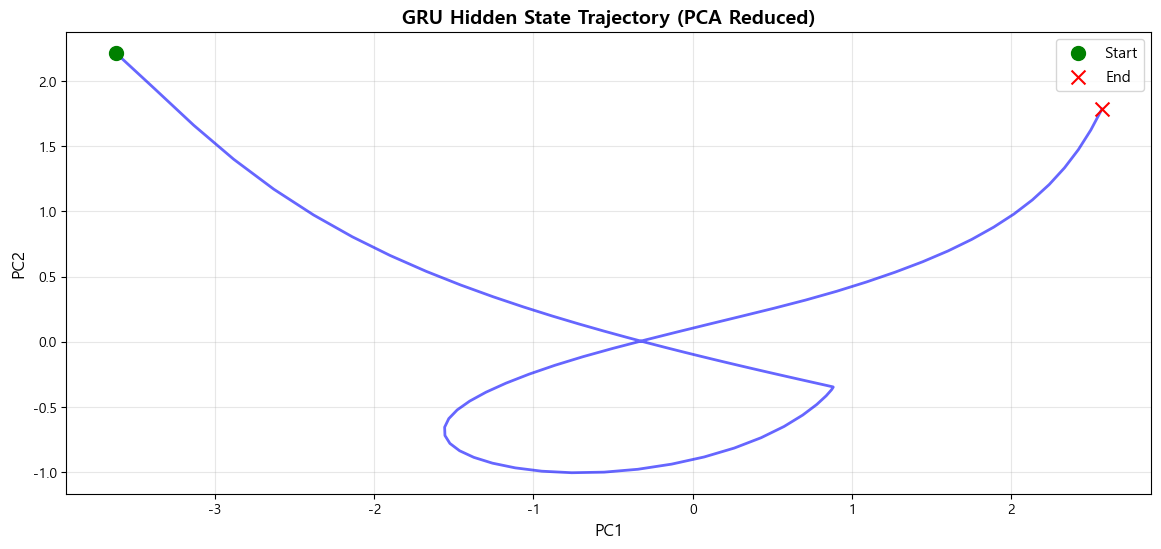

 Hidden State trajectory 시각화 완료
 시퀀스 길이: 100 steps
 Hidden dim: 128


In [8]:
# ============================================================================
# [Cell 8] ANN vs PINN vs GRU 비교 분석
# ============================================================================
# GRU Hidden State 시각화 (시퀀스 동안의 변화)
print("\n[GRU Hidden State 분석]")
print("시퀀스 진행에 따른 Hidden State 변화 확인...")

# 테스트 데이터에서 하나의 시퀀스 추출
model = pinn_gru_model.gru
model.eval()

with torch.no_grad():
    sample_x, sample_target = test_dataset[0]
    sample_x = sample_x.unsqueeze(0).to(device)  # (1, seq_len, input_dim)
    
    # Hidden State 초기화
    hidden = model.init_hidden(1)
    
    # 각 타임스텝별로 Hidden State 기록
    hidden_states = []
    for t in range(sample_x.size(1)):
        _, hidden = model(sample_x[:, t:t+1, :], hidden)
        current_hidden = hidden[-1, 0, :] 
        hidden_states.append(current_hidden.cpu().numpy())
    
    hidden_states = np.array(hidden_states).squeeze()  # (seq_len, hidden_dim)
print(f" Hidden State 데이터 형상: {hidden_states.shape} (2차원이어야 함)")
# Hidden State 변화 시각화
plt.figure(figsize=(14, 6))

# PCA로 2D로 축소
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
hidden_2d = pca.fit_transform(hidden_states)

plt.plot(hidden_2d[:, 0], hidden_2d[:, 1], 'b-', linewidth=2, alpha=0.6)
plt.scatter(hidden_2d[0, 0], hidden_2d[0, 1], c='green', s=100, 
           marker='o', label='Start', zorder=5)
plt.scatter(hidden_2d[-1, 0], hidden_2d[-1, 1], c='red', s=100, 
           marker='x', label='End', zorder=5)

plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('GRU Hidden State Trajectory (PCA Reduced)', 
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('./data/simulated/gru_hidden_state.png', dpi=150)
plt.show()

print(f" Hidden State trajectory 시각화 완료")
print(f" 시퀀스 길이: {len(hidden_states)} steps")
print(f" Hidden dim: {hidden_states.shape[1]}")

발사 시점 감지: 555.76s

GRU용 실제 데이터 준비 완료
   원본 데이터 길이: 335 steps
   GRU 입력 시퀀스: torch.Size([236, 100, 6]) (N, 100, 6)
GRU 추론 완료


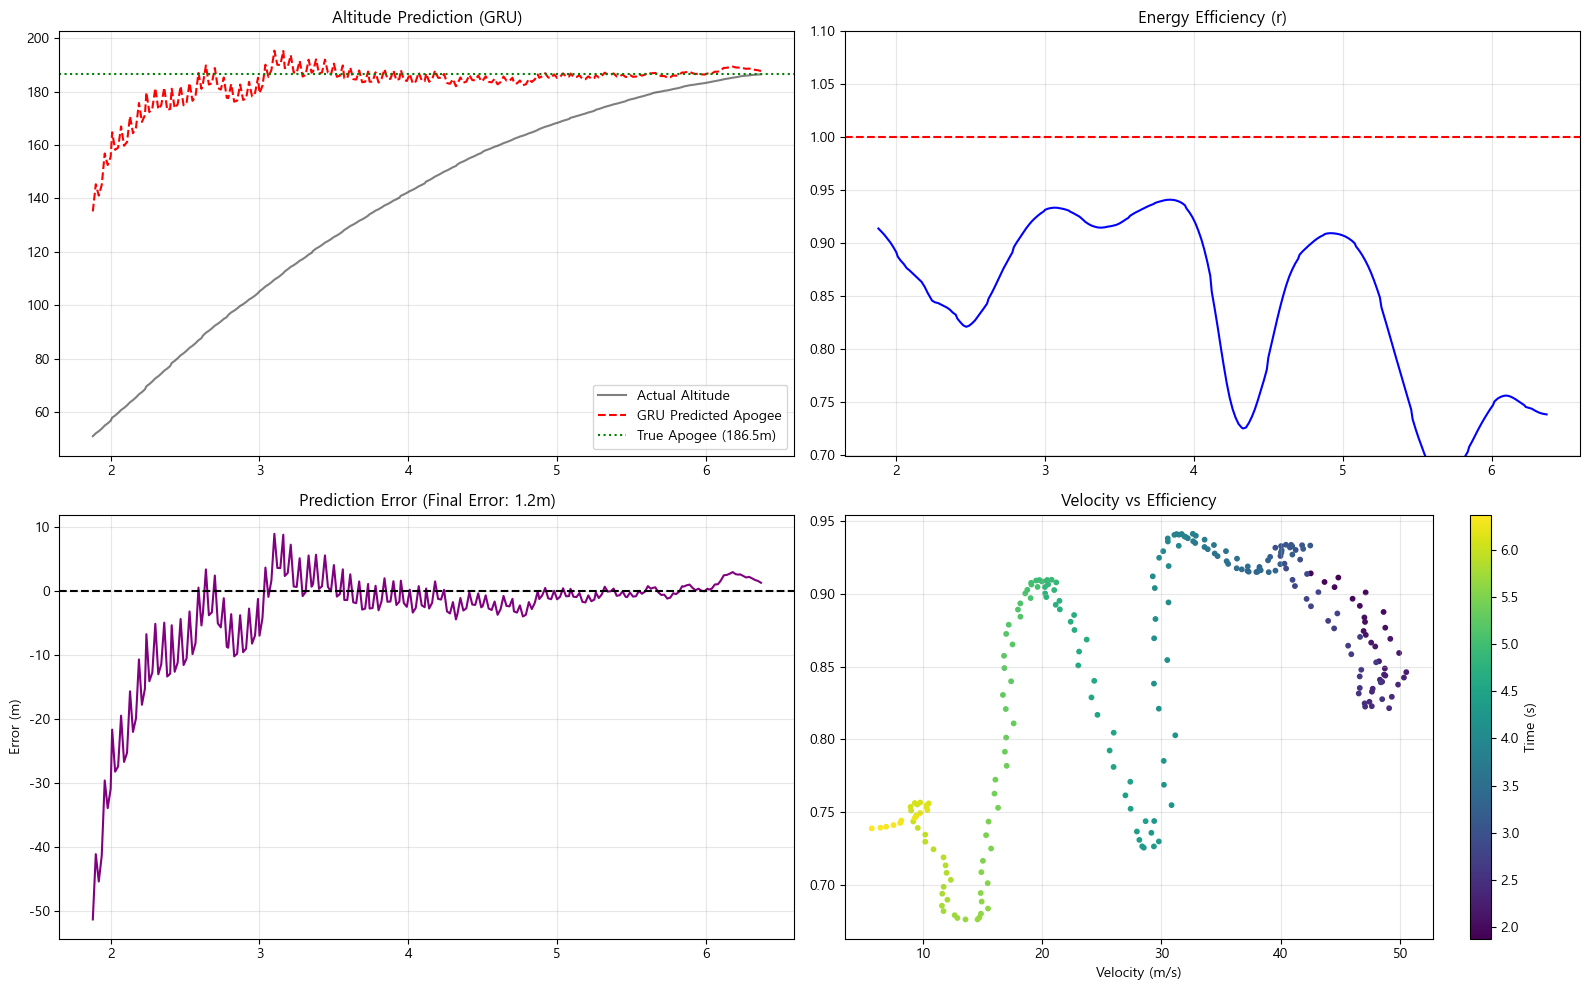


[최종 성능 리포트]
   실제 아포지: 186.46 m
   GRU 최종 예측: 187.70 m
   최종 오차: 1.24 m


In [9]:
# ============================================================================
# [Cell 9] 실제 비행 데이터(112.txt) 로드 및 GRU 검증
# ============================================================================
import re

def load_real_data_for_gru(file_path, scaler, feature_cols, window_size=100):
    """
    실제 비행 데이터를 로드하고 Sliding Window를 적용하여 GRU 입력 형태로 변환함.
    """
    # 1. 텍스트 파싱 및 데이터프레임 생성 (기존 로직 재사용)
    pattern = re.compile(
        r"Time:\s*([\d\.]+)s.*"
        r"Euler:\s*\(([-\d\.]+),\s*([-\d\.]+),\s*([-\d\.]+)\).*"
        r"Gyro:\s*\(([-\d\.]+),\s*([-\d\.]+),\s*([-\d\.]+)\).*"
        r"Accel:\s*\([^,]+,\s*[^,]+,\s*([-\d\.]+)\).*"
        r"kal:\s*\(alt\s*:\s*([\d\.]+),\s*velo\s*:\s*([\d\.]+)"
    )

    try:
        with open(file_path, 'r', encoding='utf-8') as f: lines = f.readlines()
    except:
        with open(file_path, 'r', encoding='cp949') as f: lines = f.readlines()

    launch_time = None
    raw_records = []
    
    for line in lines:
        match = pattern.search(line)
        if match:
            t_sys = float(match.group(1))
            acc_g = float(match.group(8))
            
            # 발사 감지 (가속도 > 0.5g)
            if launch_time is None and acc_g > 0.5:
                launch_time = t_sys
                print(f"발사 시점 감지: {t_sys}s")
            
            if launch_time is not None:
                # 피처 추출 및 계산
                time = t_sys - launch_time
                alt = float(match.group(9))
                vel = float(match.group(10))
                acc_ms = acc_g * 9.80665
                pitch = float(match.group(3))
                yaw = float(match.group(4))
                gyro_z = float(match.group(7)) # Roll rate
                
                # Tilt Angle 계산
                rad_yaw = np.deg2rad(yaw)
                rad_pitch = np.deg2rad(pitch)
                cos_val = np.clip(np.cos(rad_pitch) * np.cos(rad_yaw), -1.0, 1.0)
                tilt_val = np.rad2deg(np.arccos(cos_val))
                
                # Dynamic Pressure 계산
                rho = 1.225 * np.exp(-0.00012 * abs(alt))
                dyn_pres = 0.5 * rho * (vel**2)
                
                raw_records.append({
                    'time': time, 'altitude': alt, 'velocity_z': vel, 
                    'acceleration_z': acc_ms, 'tilt_angle': tilt_val, 
                    'gyro_roll': gyro_z, 'dynamic_pressure': dyn_pres
                })

    df_real = pd.DataFrame(raw_records)
    
    # 2. 피처 정규화
    # 학습 때 사용한 feature_scaler를 반드시 사용해야 함
    X_raw = df_real[feature_cols].values
    X_scaled = scaler.transform(X_raw)
    
    # 3. Sliding Window 적용 (GRU용 3D 텐서 생성)
    sequences = []
    times = []
    h_currs = []
    v_zs = []
    
    # 데이터가 윈도우 크기보다 작으면 패딩하거나 스킵
    if len(X_scaled) < window_size:
        print("경고: 데이터 길이가 윈도우 크기보다 작습니다.")
        return None, None, None, None, None

    for i in range(len(X_scaled) - window_size + 1):
        # (window_size, features)
        seq = X_scaled[i : i + window_size]
        sequences.append(seq)
        
        # 해당 시퀀스의 마지막 시점 정보 저장
        last_idx = i + window_size - 1
        times.append(df_real.iloc[last_idx]['time'])
        h_currs.append(df_real.iloc[last_idx]['altitude'])
        v_zs.append(df_real.iloc[last_idx]['velocity_z'])
        
    X_tensor = torch.FloatTensor(np.array(sequences))
    h_curr_tensor = torch.FloatTensor(np.array(h_currs))
    v_z_tensor = torch.FloatTensor(np.array(v_zs))
    time_array = np.array(times)
    
    return X_tensor, h_curr_tensor, v_z_tensor, time_array, df_real

# ---------------------------------------------------------
# 실행 및 검증
# ---------------------------------------------------------
file_path = './data/112.txt'  # 경로 확인
window_size = 100             # 학습 시 설정한 Window Size와 동일해야 함

# 학습된 Scaler 가져오기
try:
    scaler = full_dataset.feature_scaler
except:
    print("경고: 학습된 Scaler를 찾을 수 없어 새로 생성합니다. 성능이 저하될 수 있습니다.")
    scaler = StandardScaler()
    # 임시 fitting (비추천)
    
# 데이터 로드 및 전처리
X_real_gru, h_real, v_real, t_real, df_real_raw = load_real_data_for_gru(
    file_path, scaler, feature_cols, window_size
)

print(f"\nGRU용 실제 데이터 준비 완료")
print(f"   원본 데이터 길이: {len(df_real_raw)} steps")
print(f"   GRU 입력 시퀀스: {X_real_gru.shape} (N, {window_size}, {len(feature_cols)})")

# GRU 추론
pinn_gru_model.eval()
with torch.no_grad():
    X_real_gru = X_real_gru.to(device)
    h_real = h_real.to(device)
    v_real = v_real.to(device)
    
    # 순전파
    h_pred_gru, r_pred_gru = pinn_gru_model(X_real_gru, h_real, v_real)
    
    # CPU로 변환
    h_pred_np = h_pred_gru.cpu().numpy().flatten()
    r_pred_np = r_pred_gru.cpu().numpy().flatten()

print("GRU 추론 완료")

# ---------------------------------------------------------
# 시각화 
# ---------------------------------------------------------
# 실제 아포지 (전체 데이터 중 최대값)
true_apogee = df_real_raw['altitude'].max()

# Window 크기만큼 앞부분 데이터는 예측값이 없음 (잘라내기)
# t_real은 이미 window 밀린 시간축임
alt_actual_aligned = df_real_raw.iloc[window_size-1:]['altitude'].values

# 오차 계산
error_gru = h_pred_np - true_apogee

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 고도 예측
axes[0, 0].plot(t_real, alt_actual_aligned, 'k-', alpha=0.5, label='Actual Altitude')
axes[0, 0].plot(t_real, h_pred_np, 'r--', label='GRU Predicted Apogee')
axes[0, 0].axhline(true_apogee, color='green', linestyle=':', label=f'True Apogee ({true_apogee:.1f}m)')
axes[0, 0].set_title('Altitude Prediction (GRU)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 에너지 효율
axes[0, 1].plot(t_real, r_pred_np, 'b-', label='Predicted Energy Ratio')
axes[0, 1].axhline(1.0, color='red', linestyle='--')
axes[0, 1].set_title('Energy Efficiency (r)')
axes[0, 1].set_ylim(0.7, 1.1)
axes[0, 1].grid(True, alpha=0.3)

# 3. 예측 오차
axes[1, 0].plot(t_real, error_gru, 'purple')
axes[1, 0].axhline(0, color='k', linestyle='--')
axes[1, 0].set_title(f'Prediction Error (Final Error: {error_gru[-1]:.1f}m)')
axes[1, 0].set_ylabel('Error (m)')
axes[1, 0].grid(True, alpha=0.3)

# 4. 속도 vs 효율
v_aligned = df_real_raw.iloc[window_size-1:]['velocity_z'].values
sc = axes[1, 1].scatter(v_aligned, r_pred_np, c=t_real, cmap='viridis', s=10)
plt.colorbar(sc, ax=axes[1, 1], label='Time (s)')
axes[1, 1].set_title('Velocity vs Efficiency')
axes[1, 1].set_xlabel('Velocity (m/s)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n[최종 성능 리포트]")
print(f"   실제 아포지: {true_apogee:.2f} m")
print(f"   GRU 최종 예측: {h_pred_np[-1]:.2f} m")
print(f"   최종 오차: {abs(h_pred_np[-1] - true_apogee):.2f} m")

In [10]:
# ============================================================================
# [Step 4 마지막 셀] Scaler 저장 (Step 5 재사용용)
# ============================================================================
import joblib
import os

# 저장 디렉토리 생성
os.makedirs('./data/simulated/', exist_ok=True)

# Feature Scaler 저장
scaler_path = './data/simulated/input_scaler.pkl'
joblib.dump(full_dataset.feature_scaler, scaler_path)
print(f"Feature Scaler 저장 완료: {scaler_path}")

# 모델 가중치 저장
torch.save(pinn_gru_model.state_dict(), './data/simulated/best_gru_model.pth')
print(f"모델 가중치 저장 완료")

metadata = {
    'feature_cols': feature_cols,
    'window_size': WINDOW_SIZE,
    'stride': STRIDE,
    'input_dim': input_dim,
    'hidden_dim': 128,
    'num_layers': 2,
    'dropout': 0.2
}
metadata_path = './data/simulated/model_metadata.pkl'
joblib.dump(metadata, metadata_path)
print(f"모델 메타데이터 저장 완료: {metadata_path}")


Feature Scaler 저장 완료: ./data/simulated/input_scaler.pkl
모델 가중치 저장 완료
모델 메타데이터 저장 완료: ./data/simulated/model_metadata.pkl
